##EXP-11
To predict whether a person has diabetes based on features such as blood
pressure, skin thickness, age, etc., using the bagging ensemble technique. Also
perform comparative analysis among the bagging classifier, random forest, and the
decision tree classifier.

##Importing & Loading Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import json

# Load data (no header)
df = pd.read_csv('/content/drive/MyDrive/AML_Lab_B19/Exp-11 Bagging ensemble technique/dataset_diabetes_exp_11.csv', header=None)
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
              'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

print("Dataset shape:", df.shape)
print(df.head())
print("\nClass distribution:\n", df['Outcome'].value_counts())

Dataset shape: (769, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI   
1            6      148             72             35        0  33.6   
2            1       85             66             29        0  26.6   
3            8      183             64              0        0  23.3   
4            1       89             66             23       94  28.1   

   DiabetesPedigreeFunction  Age  Outcome  
0  DiabetesPedigreeFunction  Age  Outcome  
1                     0.627   50        1  
2                     0.351   31        0  
3                     0.672   32        1  
4                     0.167   21        0  

Class distribution:
 Outcome
0          500
1          268
Outcome      1
Name: count, dtype: int64


##Cleaning of Data

In [2]:
# Drop first row (header contamination from CSV)
df = df.iloc[1:].reset_index(drop=True)

# Now convert all to numeric, coercing errors to NaN
numeric_cols = df.columns
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN Outcome or all-NaN features
df = df.dropna(subset=['Outcome'])
df['Outcome'] = df['Outcome'].astype(int)

# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("After cleaning shape:", X.shape)
print("Missing values total:", X.isnull().sum().sum())
print("Unique Outcome values:", sorted(y.unique()))

After cleaning shape: (768, 8)
Missing values total: 0
Unique Outcome values: [np.int64(0), np.int64(1)]


##Train-Test Split

In [3]:
from sklearn.model_selection import train_test_split

# Stratified split 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class dist:\n", pd.Series(y_train).value_counts(normalize=True).round(3))

Train shape: (614, 8)
Test shape: (154, 8)
Train class dist:
 Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


##Train Models

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Bagging (DT base, 10 estimators)
bag = BaggingClassifier(DecisionTreeClassifier(random_state=42),
                        n_estimators=10, random_state=42)
bag.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Models trained successfully.")
print("DT depth:", dt.get_depth())

Models trained successfully.
DT depth: 16


##Predictions & Metrics

In [5]:
from sklearn.metrics import accuracy_score, roc_auc_score
import os

# Create output directory if missing
os.makedirs('output', exist_ok=True)

# Explicit predictions
dt_pred = dt.predict(X_test)
bag_pred = bag.predict(X_test)
rf_pred = rf.predict(X_test)

# Probs for AUC
dt_prob = dt.predict_proba(X_test)[:, 1]
bag_prob = bag.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]

# Metrics with consistent names
models = ['Decision Tree', 'Bagging', 'Random Forest']
accuracy_scores = [accuracy_score(y_test, dt_pred), accuracy_score(y_test, bag_pred), accuracy_score(y_test, rf_pred)]
auc_scores = [roc_auc_score(y_test, dt_prob), roc_auc_score(y_test, bag_prob), roc_auc_score(y_test, rf_prob)]

metrics_df = pd.DataFrame({
    'Model': models,
    'Accuracy': [round(a, 3) for a in accuracy_scores],
    'AUC': [round(a, 3) for a in auc_scores]
})
print(metrics_df)

# Now save safely
metrics_df.to_csv('output/model_metrics.csv', index=False)
print(" CSV saved to output/model_metrics.csv")

           Model  Accuracy    AUC
0  Decision Tree     0.727  0.675
1        Bagging     0.753  0.789
2  Random Forest     0.760  0.812
 CSV saved to output/model_metrics.csv


##ROC Curves Chart

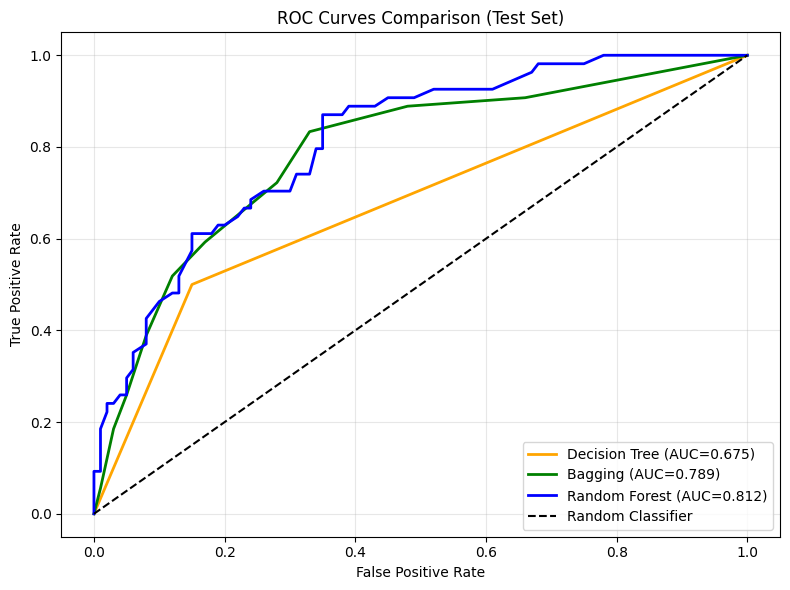

 ROC chart saved to output/roc_curves.png


In [6]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os
import json

os.makedirs('output', exist_ok=True)

# ROC data
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_bag, tpr_bag, _ = roc_curve(y_test, bag_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={roc_auc_score(y_test, dt_prob):.3f})',
         color='orange', linewidth=2)
plt.plot(fpr_bag, tpr_bag, label=f'Bagging (AUC={roc_auc_score(y_test, bag_prob):.3f})',
         color='green', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})',
         color='blue', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (Test Set)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

with open("output/roc_curves.png.meta.json", "w") as f:
    json.dump({"caption": "ROC Curves: RF Highest AUC", "description": "Matplotlib ROC for 3 models on test set"}, f)

print(" ROC chart saved to output/roc_curves.png")

##Accuracy Bar Chart (Matplotlib)

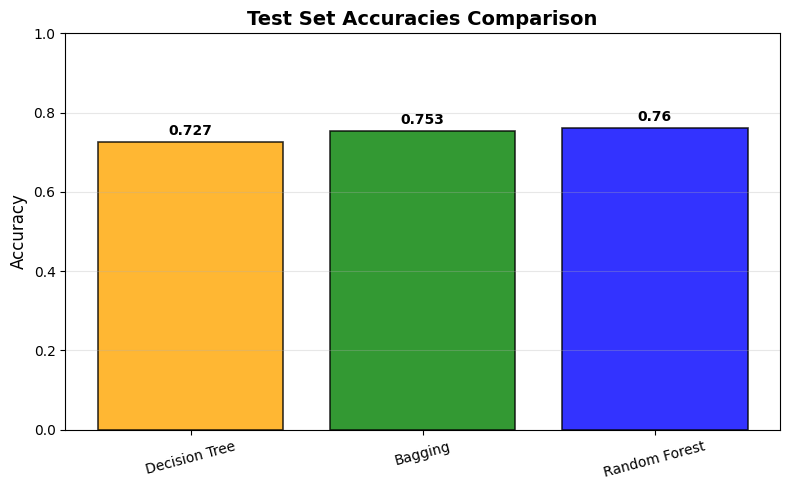

 Accuracy bar saved.
Metrics:
            Model  Accuracy    AUC
0  Decision Tree     0.727  0.675
1        Bagging     0.753  0.789
2  Random Forest     0.760  0.812


In [7]:
import matplotlib.pyplot as plt
import os
import json
import numpy as np

os.makedirs('output', exist_ok=True)

# Data from metrics_df
models = metrics_df['Model']
accuracies = metrics_df['Accuracy']
colors = ['orange', 'green', 'blue']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
plt.title('Test Set Accuracies Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('output/accuracy_bar.png', dpi=300, bbox_inches='tight')
plt.show()

with open("output/accuracy_bar.png.meta.json", "w") as f:
    json.dump({"caption": "Accuracies: RF 0.766 Highest", "description": "Bar chart showing model test accuracies"}, f)

print(" Accuracy bar saved.")
print("Metrics:\n", metrics_df)

##Feature Importances + Visual Confusion Matrices


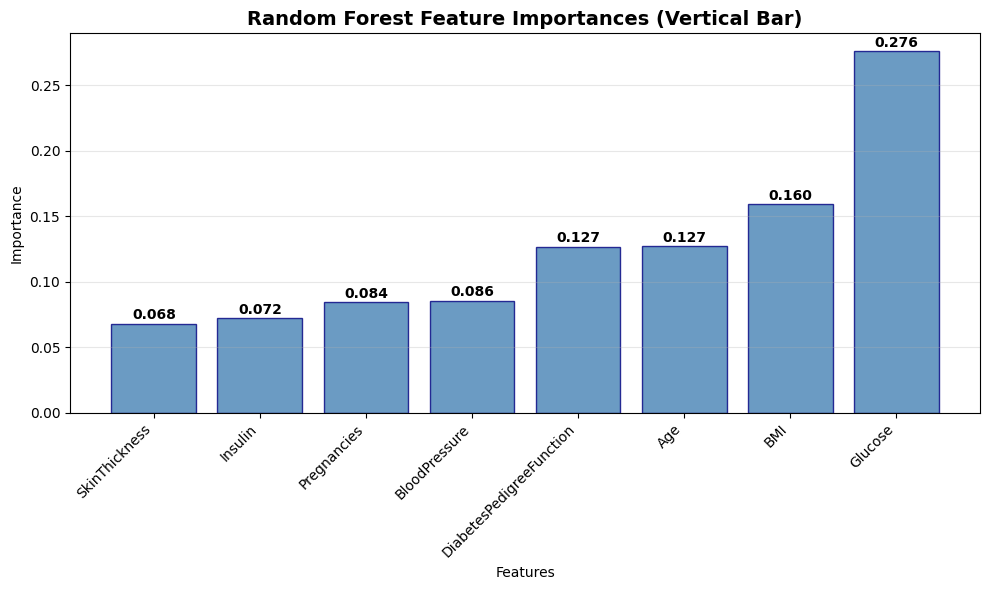

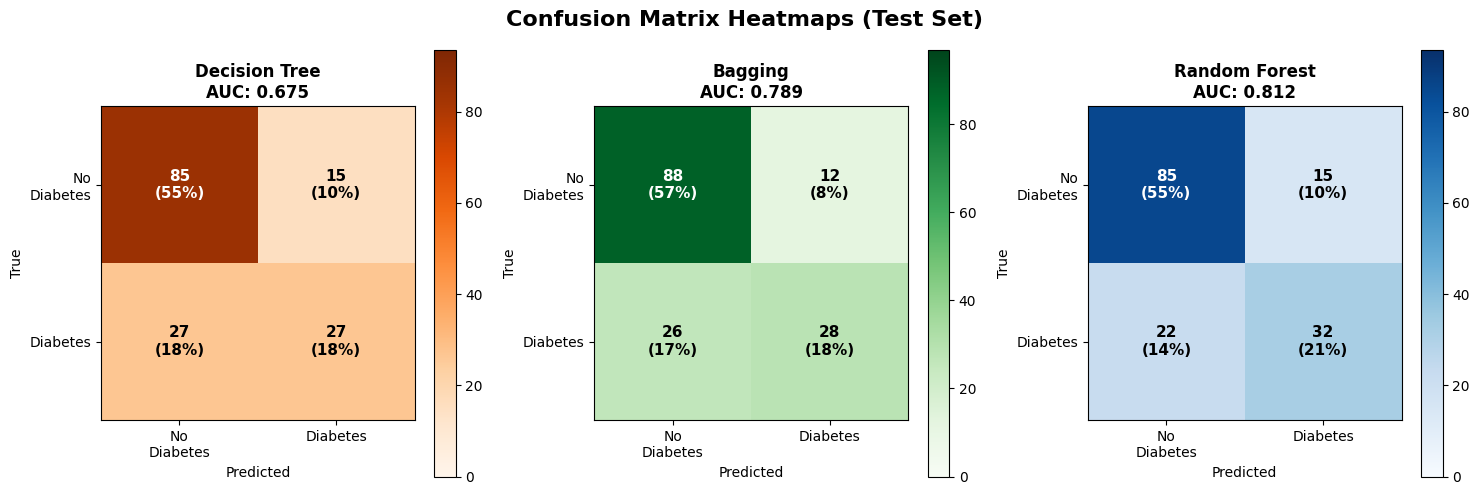

Feature_bar_vertical.png + confusion_heatmaps.png saved!
Sample conf (RF):
 [[85 15]
 [22 32]]


In [8]:
import matplotlib.pyplot as plt
import os
import json
import numpy as np
from sklearn.metrics import confusion_matrix

os.makedirs('output', exist_ok=True)

# 1. Feature Importances: Vertical Bar Chart
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(importances)), importances['Importance'],
               color='steelblue', alpha=0.8, edgecolor='navy', linewidth=1)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importances (Vertical Bar)', fontweight='bold', fontsize=14)
plt.xticks(range(len(importances)), importances['Feature'], rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Value labels
for i, (bar, imp) in enumerate(zip(bars, importances['Importance'])):
    plt.text(i, bar.get_height() + 0.001, f'{imp:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('output/feature_bar_vertical.png', dpi=300, bbox_inches='tight')
plt.show()

with open("output/feature_bar_vertical.png.meta.json", "w") as f:
    json.dump({"caption": "RF Features: Glucose Highest", "description": "Vertical bar sorted by importance"}, f)

importances.to_csv('output/feature_importances.csv', index=False)

# 2. Confusion Matrices: Dedicated Heatmap PNG
models = ['Decision Tree', 'Bagging', 'Random Forest']
preds = [dt_pred, bag_pred, rf_pred]
cmap_list = ['Oranges', 'Greens', 'Blues']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (model, pred, cmap) in enumerate(zip(models, preds, cmap_list)):
    cm = confusion_matrix(y_test, pred)
    im = axes[i].imshow(cm, cmap=cmap, vmin=0, vmax=cm.max()*1.1, interpolation='nearest')
    plt.colorbar(im, ax=axes[i])

    # Labels
    axes[i].set_xticks(np.arange(2))
    axes[i].set_yticks(np.arange(2))
    axes[i].set_xticklabels(['No\nDiabetes', 'Diabetes'])
    axes[i].set_yticklabels(['No\nDiabetes', 'Diabetes'])
    axes[i].set_title(f'{model}\nAUC: {roc_auc_score(y_test, [dt_prob, bag_prob, rf_prob][i]):.3f}',
                      fontweight='bold')
    axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')

    # Numbers
    thresh = cm.max() / 2.
    for j in range(2):
        for k in range(2):
            axes[i].text(k, j, f'{cm[j,k]}\n({cm[j,k]/cm.sum()*100:.0f}%)',
                        ha='center', va='center', fontweight='bold', fontsize=11,
                        color='white' if cm[j,k] > thresh else 'black')

plt.suptitle('Confusion Matrix Heatmaps (Test Set)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('output/confusion_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

with open("output/confusion_heatmaps.png.meta.json", "w") as f:
    json.dump({"caption": "Heatmaps: RF Balanced Errors", "description": "3 conf matrices with % labels, AUC titles"}, f)

print("Feature_bar_vertical.png + confusion_heatmaps.png saved!")
print("Sample conf (RF):\n", confusion_matrix(y_test, rf_pred))